# Introduction to Artificial Neural Networks

Deep learning is where much of the recent innovation in machine learning for
climate science and environmental sustainability is happening. In this section we
will:

- Define the **artificial neural network** (ANN) and see how it generalizes the
  linear models we've already met.
- Understand **activation functions** and where the non-linearity of a neural
  network comes from.
- Walk through the steps and best practices to **build a neural network in
  practice**.
- Know the main **hyperparameters** that define a network's architecture and the
  ones that control its training.
- Discuss applications of neural networks to **climate model parameterizations and
  tuning**.

The figures in the first part of this page are all generated from data with a few
lines of `numpy` and scikit-learn's built-in multilayer perceptron, so you can see
each idea rather than take it on faith.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.metrics import r2_score, log_loss

warnings.filterwarnings("ignore")   # silence sklearn convergence chatter for a clean page
np.random.seed(0)

## From biological to artificial neural networks

The conceptual roots of the neural network were recognized by the **2024 Nobel
Prize in Physics**, awarded to John Hopfield and Geoffrey Hinton. Hopfield
introduced the **Hopfield network** (1982), a simple recurrent network that can
store and recall patterns, drawing on ideas from statistical physics. Hinton and
collaborators introduced the **Boltzmann machine**, a stochastic neural network in
which nodes make probabilistic decisions about being on or off. Both were
foundational ideas that led to what we now call the artificial neural network.

The name comes from a loose analogy with the brain. A biological neuron accumulates
a membrane potential and, once it crosses a threshold, "fires" — the synapse
activates. An artificial neural network mimics this with **activation functions**
that introduce non-linearities between layers. The biological version is far more
complicated, but even this simple analogy is enough to build a system that can learn
essentially any non-linear function.

## The perceptron and the fully connected layer

The simplest neural network is the **perceptron**. We take some inputs, multiply
them by weights, and apply a step-function activation: negative values map to 0,
positive values map to 1, producing a single output. This was a forerunner of the
modern neural network.

Instead of a single output, we can connect the inputs to a whole layer of outputs —
a **fully connected layer**. Each input connects to every unit in the next layer
through a learned weight, and an activation function is applied. Written out, a
layer looks very much like linear regression:

$$
\text{output} = \phi\left( W\,\mathbf{x} + \mathbf{b} \right)
$$

where $\mathbf{x}$ is the **input vector**, $W$ is the **weight matrix**,
$\mathbf{b}$ is the **bias vector** (the intercept), and $\phi$ is the **activation
function**. The only thing that distinguishes this from linear regression is the
non-linear $\phi$ applied to the weighted sum.

## From a layer to a Multilayer Perceptron

Stacking fully connected layers gives a **Multilayer Perceptron (MLP)**, also called
a feedforward neural network. With a single hidden layer, the input features
$x_1, x_2, \ldots$ (there could be a hundred of them) are combined by a learned
weight matrix, passed through an activation to produce a **hidden layer**, and then
combined again to produce the output:

$$
\text{Hidden} = \phi_{\text{bottom}}\left( W_{\text{bottom}}\,\text{Input} + \mathbf{b}_{\text{bottom}} \right)
$$

$$
\text{Output} = \phi_{\text{top}}\left( W_{\text{top}}\,\text{Hidden} + \mathbf{b}_{\text{top}} \right)
$$

A useful rule of thumb for depth:

- **1 layer** ≈ logistic regression (with a step/logistic activation),
- **2 layers** = a *shallow* neural network,
- **3 or more layers** = *deep* learning.

The hidden layers hold **hidden variables** — higher-dimensional features the
network learns for the specific problem. Unlike linear regression, where a weight
multiplying "temperature" or "precipitation" has a direct interpretation, these
hidden features are hard to read off directly. This is why neural networks are often
described as **black boxes**: the input-to-output mapping passes through many
non-linear activations and becomes difficult to interpret. **Explainable-AI (XAI)**
techniques exist to probe *why* a network produces the mapping it does, but
interpretability remains a genuine trade-off for the flexibility neural networks
buy us.

## Activation functions — where the non-linearity arises

Activation functions are the "magic" of neural networks: they are where the
non-linearity comes from. Without them, a stack of linear layers — even hundreds of
them — could be rewritten as a *single* linear transformation, and the network could
not represent non-linear functions.

Each row below shows one activation function (left) alongside its derivative (right).
**ReLU** zeros out negatives and keeps positives unchanged (note its abrupt,
stepwise derivative). **Sigmoid** and **tanh** squash their inputs into a bounded
range with smooth derivatives — useful when you want to constrain an output to a
known physical range. **Leaky ReLU** and **ELU** keep a small response for negative
inputs to preserve gradient flow.

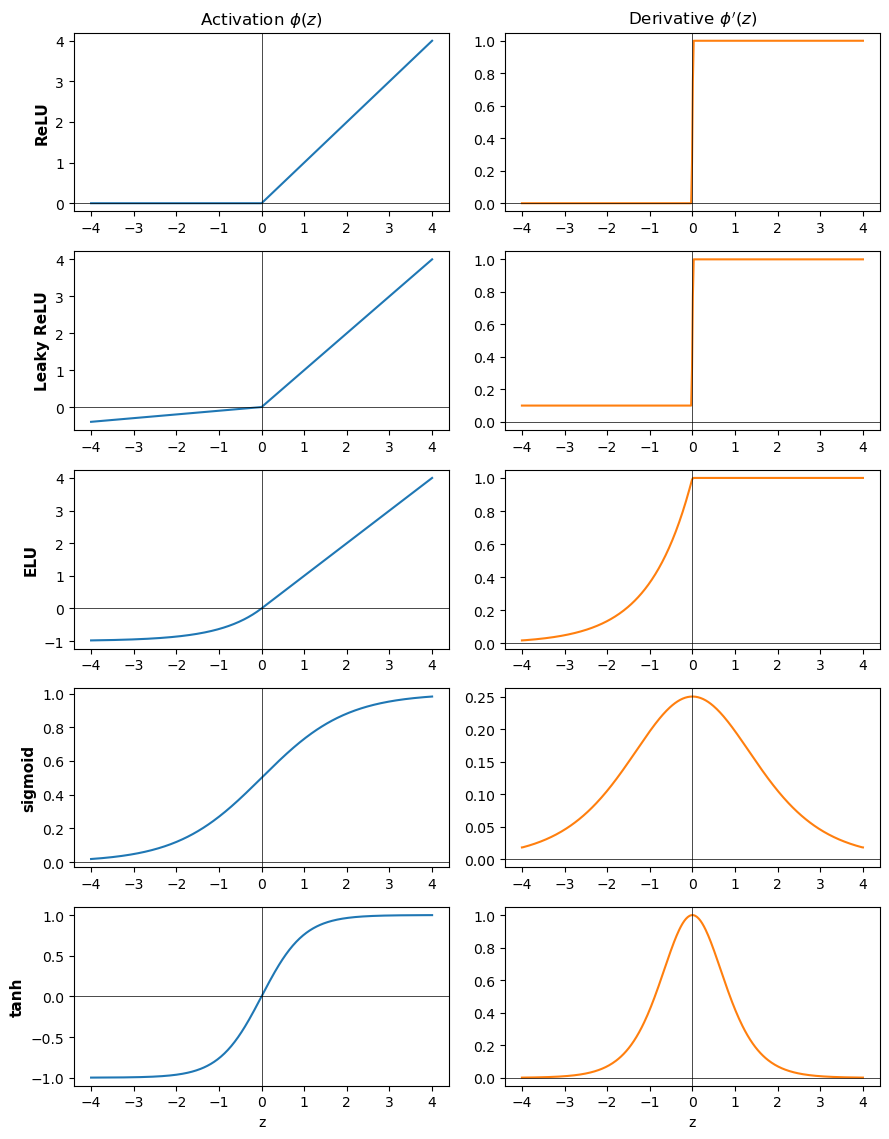

In [2]:
z = np.linspace(-4, 4, 400)

def relu(z):         return np.maximum(0.0, z)
def leaky(z, a=0.1): return np.where(z > 0, z, a * z)
def elu(z, a=1.0):   return np.where(z > 0, z, a * (np.exp(z) - 1))
sigmoid = 1.0 / (1.0 + np.exp(-z))
tanh    = np.tanh(z)

funcs = {"ReLU": relu(z), "Leaky ReLU": leaky(z), "ELU": elu(z),
         "sigmoid": sigmoid, "tanh": tanh}

# one row per activation: function on the left, its derivative on the right
fig, axes = plt.subplots(len(funcs), 2, figsize=(9, 2.3 * len(funcs)))
for row, (name, yv) in enumerate(funcs.items()):
    axL, axR = axes[row]
    axL.plot(z, yv, color="C0")
    axR.plot(z, np.gradient(yv, z), color="C1")
    axL.set_ylabel(name, fontsize=11, fontweight="bold")
    for ax in (axL, axR):
        ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    if row == 0:
        axL.set_title(r"Activation $\phi(z)$"); axR.set_title(r"Derivative $\phi'(z)$")
    if row == len(funcs) - 1:
        axL.set_xlabel("z"); axR.set_xlabel("z")
plt.tight_layout(); plt.show()

## Neural networks as universal approximators

One of the real powers of neural networks is that they are **universal function
approximators**. The **Universal Approximation Theorem** (Cybenko & Hornik, 1989;
Leshno et al., 1993) says that by making a network **wide enough** (enough weights
per layer) *or* **deep enough** (enough layers), it can represent any continuous
function.

This goes **beyond linear functions**. Linear regression (even polynomial
regression) learns weights that scale the inputs in a way we can write down. A neural
network can approximate genuinely non-linear functions. Below we fit both a linear
regression and an MLP to the same non-linear,
noisy target. The linear model can only draw a straight line; the MLP follows the
curve. The printed $R^2$ scores make the difference concrete (higher is better; a
straight line through curved data scores poorly).

Linear regression R^2 : 0.349
MLP (64, 64)      R^2 : 0.984


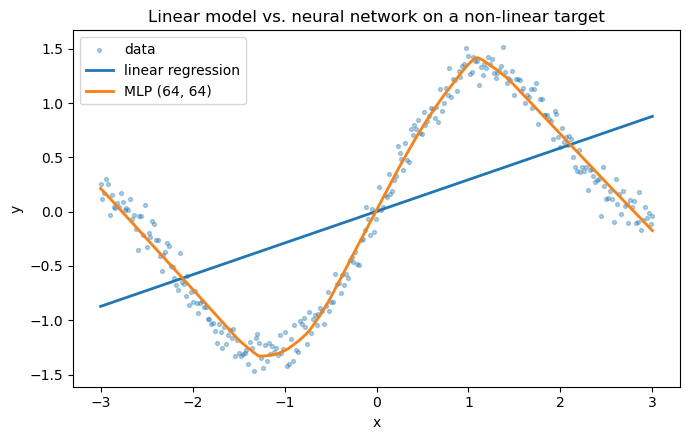

In [3]:
# A non-linear 1-D target with a little noise
X = np.linspace(-3, 3, 300).reshape(-1, 1)
y = np.sin(1.5 * X).ravel() + 0.3 * X.ravel() + 0.1 * np.random.randn(X.shape[0])

Xs = StandardScaler().fit_transform(X)                    # scale inputs for the MLP
linear = LinearRegression().fit(X, y)
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), activation="relu",
                   max_iter=4000, random_state=0).fit(Xs, y)

y_lin, y_mlp = linear.predict(X), mlp.predict(Xs)
print(f"Linear regression R^2 : {r2_score(y, y_lin):.3f}")
print(f"MLP (64, 64)      R^2 : {r2_score(y, y_mlp):.3f}")

plt.figure(figsize=(7, 4.5))
plt.scatter(X, y, s=8, alpha=0.35, label="data")
plt.plot(X, y_lin, lw=2, label="linear regression")
plt.plot(X, y_mlp, lw=2, label="MLP (64, 64)")
plt.title("Linear model vs. neural network on a non-linear target")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.tight_layout(); plt.show()

### Wide enough to approximate

"Wide enough" is also an important point. The same target is fit below by MLPs with a
single hidden layer of increasing width. A network with only a couple of hidden
units can bend the line a little; adding units lets it track the curve ever more
closely, with the $R^2$ climbing accordingly.

hidden width  1: R^2 = 0.434
hidden width  4: R^2 = 0.515
hidden width 16: R^2 = 0.988


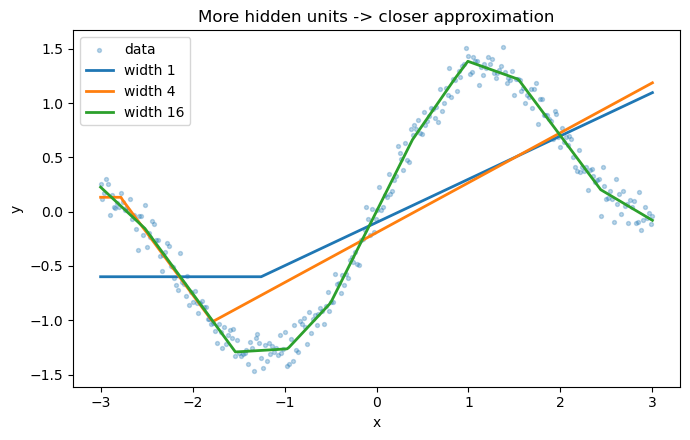

In [4]:
widths = [1, 4, 16]
plt.figure(figsize=(7, 4.5))
plt.scatter(X, y, s=8, alpha=0.3, label="data")
for w in widths:
    m = MLPRegressor(hidden_layer_sizes=(w,), activation="relu", solver="lbfgs",
                     max_iter=8000, random_state=0).fit(Xs, y)
    print(f"hidden width {w:2d}: R^2 = {r2_score(y, m.predict(Xs)):.3f}")
    plt.plot(X, m.predict(Xs), lw=2, label=f"width {w}")
plt.title("More hidden units -> closer approximation")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.tight_layout(); plt.show()

## Learning the weights: backpropagation

The parameters a network must learn are the **weight matrices** and **bias vectors**
of every layer — and there can be very many of them. A deep network can have
hundreds of thousands of weights.

Training uses **backpropagation**:

1. **Forward pass.** With the current weights, propagate the inputs through the
   layers (applying weights and activations) to produce predictions.
2. **Loss.** Evaluate a loss function comparing predictions to targets.
3. **Backward pass.** Compute the **gradient of the loss** with respect to every
   weight, and take a step that reduces the loss.

Gradients are computed by **automatic differentiation**, which applies the chain
rule sequentially over the network's computational graph to get exact gradients.

A key difficulty is the **exploding / vanishing gradient problem**: repeated
multiplication by large (or small) factors through the chain rule can make weights
unstable, so the loss oscillates or diverges (exploding), or stops updating
(vanishing). This is especially challenging for deep networks. Many remedies exist —
gradient clipping, careful **weight initialization**, smaller learning rates, batch
normalization, residual connections, and the choice of activation function.

### The loss landscape and the learning rate

The **learning rate** tells gradient descent how far to move the weights at each
step. We can see why it matters on a problem simple enough to draw: fitting a line
$y = w\,x + b$ by minimizing mean squared error gives a bowl-shaped **loss surface**
over the two parameters $(w, b)$. Gradient descent walks downhill toward the minimum.
The three paths below start from the same point with different learning rates.

too small (0.02)     -> final (w, b) = (    1.16,     0.30), final loss = 9.91e-01
well chosen (0.3)    -> final (w, b) = (    2.06,     0.99), final loss = 8.70e-02
too large (1.02)     -> final (w, b) = ( 3920.90, -6692.61), final loss = 6.65e+07
(true parameters used to generate the data: w = 2.0, b = 1.0)


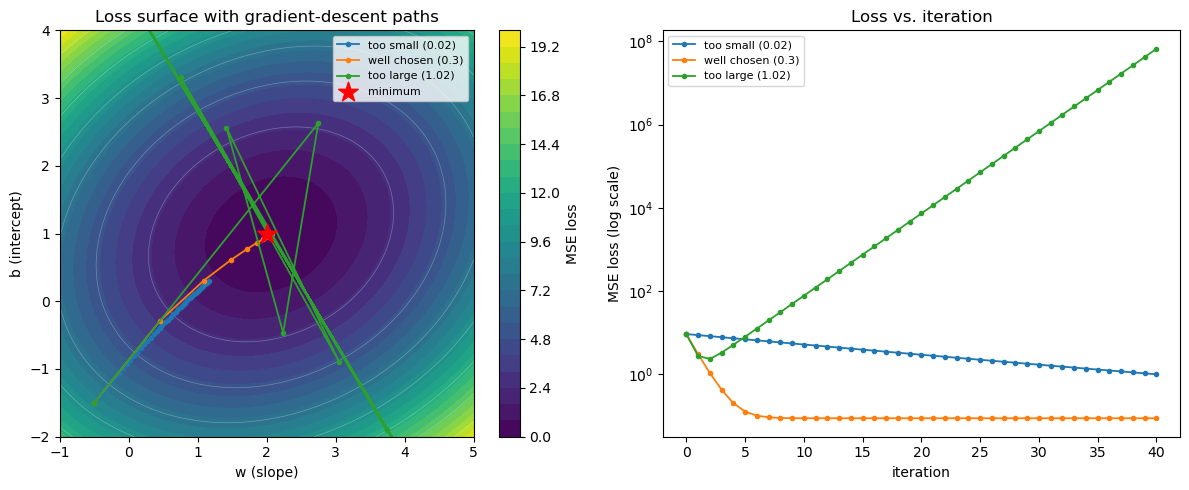

In [5]:
# Toy linear data; the MSE of a line y = w*x + b is a bowl over the two parameters
xd = np.random.randn(80)
yd = 2.0 * xd + 1.0 + 0.3 * np.random.randn(80)

def mse(w, b):
    p = w * xd + b
    return np.mean((p - yd) ** 2)

def grad(w, b):
    p = w * xd + b
    return 2 * np.mean((p - yd) * xd), 2 * np.mean(p - yd)

# evaluate the loss surface on a grid of (w, b)
ws = np.linspace(-1, 5, 200); bs = np.linspace(-2, 4, 200)
WW, BB = np.meshgrid(ws, bs)
ZZ = np.array([[mse(w, b) for w in ws] for b in bs])

def descend(lr, steps=40, start=(-0.5, -1.5)):
    w, b = start; path = [(w, b)]; loss = [mse(w, b)]
    for _ in range(steps):
        gw, gb = grad(w, b); w -= lr * gw; b -= lr * gb
        path.append((w, b)); loss.append(mse(w, b))
    return np.array(path), np.array(loss)

rates = {"too small (0.02)": 0.02, "well chosen (0.3)": 0.3, "too large (1.02)": 1.02}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))
cf = axL.contourf(WW, BB, ZZ, levels=30, cmap="viridis")
fig.colorbar(cf, ax=axL, label="MSE loss")
axL.contour(WW, BB, ZZ, levels=8, colors="white", alpha=0.3, linewidths=0.5)
for label, lr in rates.items():
    path, loss = descend(lr)
    axL.plot(path[:, 0], path[:, 1], marker="o", ms=3, lw=1.3, label=label)
    axR.plot(loss, marker="o", ms=3, lw=1.3, label=label)
    print(f"{label:20s} -> final (w, b) = ({path[-1,0]:8.2f}, {path[-1,1]:8.2f}), "
          f"final loss = {loss[-1]:.2e}")
print("(true parameters used to generate the data: w = 2.0, b = 1.0)")
axL.scatter([2.0], [1.0], c="red", marker="*", s=220, zorder=5, label="minimum")
axL.set(title="Loss surface with gradient-descent paths", xlabel="w (slope)",
        ylabel="b (intercept)", xlim=(-1, 5), ylim=(-2, 4))
axL.legend(fontsize=8, loc="upper right")
axR.set(title="Loss vs. iteration", xlabel="iteration", ylabel="MSE loss (log scale)",
        yscale="log")
axR.legend(fontsize=8)
plt.tight_layout(); plt.show()

The colored surface on the **left** is the bowl-shaped loss (darker = lower), with its
minimum at the true $(w, b) = (2, 1)$ marked by a star. Three gradient-descent runs
start from the same lower-left corner. With **too small** a learning rate the point
crawls and barely leaves the corner in the budget of steps; with a **well-chosen** rate
it descends straight to the minimum; with **too large** a rate the steps overshoot and
shoot out of the frame — the loss diverges. The **right** panel shows the same three
runs as **loss versus iteration** (log scale): the well-chosen rate drops steeply toward
zero, the too-small rate decreases but stalls far above it, and the too-large rate
*climbs* as it diverges. Real networks have millions of parameters, so this landscape is
vastly higher-dimensional, but the intuition carries over.

## Building a neural network in practice

The workflow parallels what we discussed earlier in the course for supervised and
unsupervised learning, with more knobs to turn:

1. **Define the problem** — classification vs. regression — which fixes the **loss
   function** (e.g., mean squared error for regression; binary/categorical
   cross-entropy for classification; mean absolute error or Huber as alternatives).
   One real constraint: because training differentiates the loss, **the loss must be
   differentiable**.
2. **Pre-process the data** — training/validation/test split, and **normalization /
   scaling** of the inputs. As with linear or logistic regression, well-scaled inputs
   make it much easier and faster to find optimal weights.
3. **Choose the architecture** and implement it in a deep-learning library.

For real deep learning we use **TensorFlow** with the **Keras** front end, or
**PyTorch** — libraries that provide automatic differentiation and GPU support.
(An **API**, Application Programming Interface, is simply a way for programs to
communicate; Keras is a high-level API for defining networks layer by layer.) For the
small illustrations on this page scikit-learn's `MLPClassifier` / `MLPRegressor` are
enough; for the assignments and larger climate problems you'll use Keras.

### Epochs, batches, and monitoring training

We rarely train on the whole dataset at once. **Stochastic gradient descent** uses a
random **batch** of the data at each step; one **epoch** is a full pass through the
training set. Training over multiple epochs, on batches, tends to find a more
*generalizable* solution — and is often a practical necessity, since image or climate
datasets can be far too large to fit in memory.

We watch the **training loss** and a held-out **validation loss** fall over epochs.
Below we train a small classifier on the two-moons dataset and record both after each
epoch. The validation loss tracks the training loss and sits slightly above it — the
expected, healthy pattern. If the validation loss instead started to **rise** while
the training loss kept falling, that would signal **overfitting**, and **early
stopping** would halt training at the turn.

final training loss   : 0.154
final validation loss : 0.158
validation accuracy   : 0.933


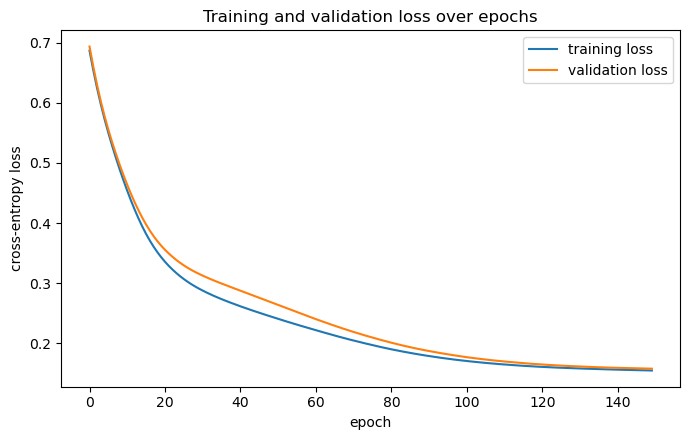

In [6]:
Xm, ym = make_moons(n_samples=1000, noise=0.25, random_state=0)
Xtr, Xval, ytr, yval = train_test_split(Xm, ym, test_size=0.3, random_state=0)
sc = StandardScaler().fit(Xtr); Xtr, Xval = sc.transform(Xtr), sc.transform(Xval)

clf = MLPClassifier(hidden_layer_sizes=(32, 32), activation="relu",
                    max_iter=1, warm_start=True, random_state=0)
train_loss, val_loss = [], []
for epoch in range(150):
    clf.partial_fit(Xtr, ytr, classes=[0, 1])
    train_loss.append(log_loss(ytr, clf.predict_proba(Xtr), labels=[0, 1]))
    val_loss.append(log_loss(yval, clf.predict_proba(Xval), labels=[0, 1]))

print(f"final training loss   : {train_loss[-1]:.3f}")
print(f"final validation loss : {val_loss[-1]:.3f}")
print(f"validation accuracy   : {clf.score(Xval, yval):.3f}")

plt.figure(figsize=(7, 4.5))
plt.plot(train_loss, label="training loss")
plt.plot(val_loss, label="validation loss")
plt.title("Training and validation loss over epochs")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss"); plt.legend()
plt.tight_layout(); plt.show()

### What overfitting looks like

The run above generalizes well. To see **overfitting**, we make the problem hard for the
model to memorize *and* generalize at once: shrink the training set, add a lot of noise,
and use a much larger network with almost no regularization. Now watch the two losses
part ways.

validation loss is lowest at epoch 26 (loss 0.386)
final training loss   : 0.145
final validation loss : 0.973  <- much higher than at its minimum


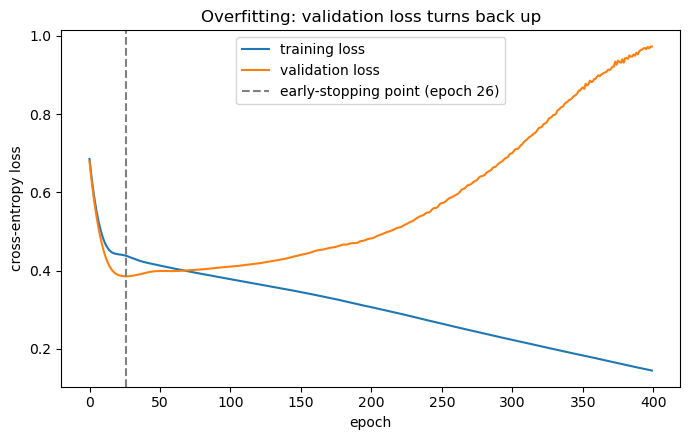

In [7]:
Xo, yo = make_moons(n_samples=120, noise=0.45, random_state=0)
Xtr2, Xval2, ytr2, yval2 = train_test_split(Xo, yo, test_size=0.4, random_state=0)
sc2 = StandardScaler().fit(Xtr2); Xtr2, Xval2 = sc2.transform(Xtr2), sc2.transform(Xval2)

over = MLPClassifier(hidden_layer_sizes=(200, 200), activation="relu", alpha=1e-6,
                     max_iter=1, warm_start=True, random_state=0)
tr_loss, va_loss = [], []
for epoch in range(400):
    over.partial_fit(Xtr2, ytr2, classes=[0, 1])
    tr_loss.append(log_loss(ytr2, over.predict_proba(Xtr2), labels=[0, 1]))
    va_loss.append(log_loss(yval2, over.predict_proba(Xval2), labels=[0, 1]))

best = int(np.argmin(va_loss))
print(f"validation loss is lowest at epoch {best} (loss {va_loss[best]:.3f})")
print(f"final training loss   : {tr_loss[-1]:.3f}")
print(f"final validation loss : {va_loss[-1]:.3f}  <- much higher than at its minimum")

plt.figure(figsize=(7, 4.5))
plt.plot(tr_loss, label="training loss")
plt.plot(va_loss, label="validation loss")
plt.axvline(best, color="gray", ls="--", label=f"early-stopping point (epoch {best})")
plt.title("Overfitting: validation loss turns back up")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss"); plt.legend()
plt.tight_layout(); plt.show()

This is the pattern the healthy run only hinted at. The **training loss keeps falling**
toward zero as the oversized network memorizes the noisy training points, but the
**validation loss bottoms out and then climbs** — past that point the model is fitting
noise, not signal, so it generalizes *worse*. **Early stopping** ends training at the
dashed line (the validation minimum), keeping the most generalizable model. More
training data and regularization (L1/L2, dropout — below) are the other standard
remedies.

### Architecture and training hyperparameters

Neural networks expose many more choices than the scikit-learn algorithms we've used:
the number of **hidden layers**, the number of **neurons per layer**, and the
**activation** at each layer and at the output. Rules of thumb: keep layer sizes near
a **power of two** to avoid bottlenecks, change sizes **gradually**, and use a
**softmax** output for classification. Beyond these heuristics, architecture design is
"more art than science."

On the training side, the key knobs are the **learning rate** (illustrated above), the
**loss function** (MSE / MAE / Huber for regression; cross-entropy for classification),
the **optimizer**, and the **batch size**. Optimizers are all variants of **stochastic
gradient descent (SGD)**: plain SGD; **SGD with momentum** (adds a velocity term);
**AdaGrad / AdaDelta / RMSprop** (adapt the learning rate during training); and
**Adam** (Adaptive Moment Estimation), which combines RMSprop and momentum and is one
of the most widely used optimizers in practice.

### Avoiding overfitting through regularization

Because networks have so many weights, they can overfit. Regularization helps:
**L1 / L2 regularization** penalizes the weights in the loss (L2 discourages large
weights; L1 encourages sparsity); **batch normalization** rescales a layer's inputs
using batch statistics; and **dropout** randomly removes weights during training,
which reduces effective capacity — and, applied at inference, is also used to add an
**uncertainty** estimate to a network that would otherwise output a single value.

---

# Neural Networks in Climate and Environmental Science

A recurring question in this field is: **how can we emulate a complex, non-linear,
high-dimensional environmental process with machine learning?** Two applications
below — emulating sub-grid parameterizations and tuning climate-model parameters —
put the universal-approximation property to work.

## Emulating sub-grid processes (parameterizations)

A climate model divides the Earth — atmosphere, ocean, land, at many vertical levels
— into a 3-D grid and steps the environmental variables forward in time. Because
climate projections run for **hundreds of years**, the models must be computationally
efficient, so grid boxes are large — a **typical grid spacing is ~25–100 km**.

Everything happening at scales **smaller than a grid box** — shallow and deep
convection, cloud microphysics, the radiative effects of clouds — still affects the
grid-box averages of temperature, humidity, and so on. These sub-grid effects are
represented by **parameterizations**: simplified models of the *aggregated* effect of
small-scale processes within a grid box over a time step.

A concrete example is **super-parameterization**. A standard atmosphere model such as
**CAM5** uses conventional parameterizations at ~100 km spacing. **SPCAM5** instead
embeds a much higher-resolution atmospheric model *inside each grid box* — far more
accurate, but so computationally expensive it cannot be used for routine long-term
climate runs. The machine-learning idea is to **train a neural network on SPCAM5** to
reproduce its sub-grid behavior, then drop that network back into the coarse model in
place of the parameterization. Because a network's **inference is fast**, the emulator
delivers close to SPCAM5 quality at a small fraction of the cost. One of the first
papers to demonstrate deep learning for sub-grid processes (published in 2018) used
exactly this setup, with super-parameterized CAM as the ground truth.

A practical obstacle is software: many climate models are written in **Fortran** —
hundreds of thousands of lines of legacy code — while the machine-learning libraries
are in **Python**. Coupling the two is genuinely hard; groups bridge Fortran and
Python, rewrite parts of the model in Python, or rebuild the model in a language like
**Julia** where these optimization approaches can be expressed directly.

## Tuning climate-model parameters

Neural networks can also *improve* a climate model without replacing its
parameterizations — by helping **tune** its parameters. Parameterizations contain many
parameters whose values start from physical understanding but are then **tuned so the
model better matches large-scale observations** (for example the **entrainment rate**
of convective clouds, or the **fall velocity** of ice crystals, which sets how
long-lived clouds are).

Doing this by hand is slow. A **perturbed-parameter ensemble (PPE)** runs the climate
model many times — say ~500 runs spanning ~40 atmospheric parameters. Because each run
is expensive, only a limited number of parameter sets can be sampled directly. A
neural network then **learns the non-linear mapping** from input parameters to model
outputs, acting as a cheap **surrogate** for the full model. With that surrogate we can
explore far more of the parameter space, study how parameters interact non-linearly,
and identify which parameters the model is most **sensitive** to — which also flags
where a process may be poorly represented physically.

### Parametric vs. structural error

Tuning often reveals that **no** parameter set fits *all* the observations well. That
points to **structural error** rather than **parametric error**:

- **Parametric error** — the equations are right but a parameter value is wrong. If a
  model is $y = w_1 x$ and $w_1$ is off, tuning $w_1$ fixes it.
- **Structural error** — the equations themselves are wrong (the truth is really
  $x^2$, not $x$). No amount of tuning the existing parameters can recover the
  observations.

Parametric errors are what tuning and PPE surrogates address. Structural errors send
us back to improve the underlying parameterizations. Either way, these tools
progressively **point to where a model can be improved**.